# Flexibility under Uncertainty

Compare fixed-horizon and threshold-policy outcomes on common market realizations, following the teaching structure in Chapters 8–10 of {cite}`farevuu2018`.

## Goal
Inspect paired PV, IRR and sale-timing distributions. The routine acceptance count is deliberately small and visible. It demonstrates reproducibility and consumer behavior; it does not estimate policy superiority reliably.

## Setup

In [1]:
%matplotlib inline
from datetime import date
from uuid import uuid4
import os, sys
import pandas as pd  # Detached tables for presentation only.
import matplotlib.pyplot as plt
import rangekeeper as rk
from rangekeeper.examples import investment
from rangekeeper.io import MemoryStore
from rangekeeper.execution import Executor
from rangekeeper.run import validate
from rangekeeper.adapters.plotting import plot_flows, plot_distribution, plot_pairs
from rangekeeper.calculations import series
from rangekeeper.model import Model, Metadata
from rangekeeper.model.flow import Flow, Movement
from rangekeeper.duration import make_periods
from rangekeeper.model.scenario import DistributionParameters
from rangekeeper.scenarios import make_plan, generate, replay
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.prop_cycle': plt.cycler(color=['#285f8f','#cf8b2e','#9c557a','#627c49','#737373'])})
print('Installed package:', rk.__file__)
assert not {'rangekeeper.flux','rangekeeper.dynamics','rangekeeper.policy','rangekeeper._legacy_duration'} & set(sys.modules)

Installed package: /private/tmp/rk-turn2-final-wheel/site/rangekeeper/__init__.py


In [2]:
def execute(model, specification):
    store = MemoryStore()
    store.put(model)
    run = Executor(store).execute(specification)
    validate(run, resolver=store).raise_if_invalid()
    assert run.report.status.solution == 'feasible', [(d.code, d.message) for d in run.report.diagnostics]
    output = store.load_model(run.record.outputs[0])
    return investment.report(output), run

def metrics(result):
    return {'PV (AUD)': result.pv.magnitude, 'NPV (AUD)': result.npv.magnitude,
            'Dated IRR (%)': 100 * result.irr.rate, 'Sale date': result.sale_date}

## Steps
### 1. Declare sampling distributions and sample size
The linked cycle method preserves the relationship between space-cycle phase and asset-cycle phase, and between their periods. Sampled proportions, offsets and magnitudes are recorded as canonical inputs.

In [3]:
FULL_SCENARIO_COUNT = 2000
SCENARIO_COUNT = int(os.environ.get('RK_SCENARIO_COUNT', '4'))
WORKERS = int(os.environ.get('RK_SCENARIO_WORKERS', '1'))
print(f'Acceptance/sample run: {SCENARIO_COUNT} scenarios; full study setting: {FULL_SCENARIO_COUNT}; workers: {WORKERS}')
# Set RK_SCENARIO_COUNT=2000 to run the original full study size.
periods = make_periods(date(2021,1,1), frequency='year', count=11)
base_model = Model.create(metadata=Metadata(id=uuid4(), schema_version='0.5.0'))
def uniform(lower, upper):
    return DistributionParameters(kind='uniform', lower=lower, upper=upper, units='dimensionless')
def pert(lower, mode, upper):
    return DistributionParameters(kind='pert', lower=lower, mode=mode, upper=upper, units='dimensionless')
plan = make_plan(periods=periods, seed=20261006, method='market.estimates.v1', parameters={
    'growth_rate': pert(-.01,.02,.05), 'cap_rate': pert(.04,.05,.07),
    'space_period': uniform(10.,20.), 'space_phase_proportion': uniform(0.,1.),
    'space_amplitude': .25, 'asset_amplitude': .01,
    'asset_phase_difference': uniform(-.1,.1), 'asset_period_difference': uniform(-1.,1.),
    'space_asymmetry': 0., 'asset_asymmetry': 0., 'volatility': .03,
    'noise_lower': -.03, 'noise_upper': .03, 'shock_likelihood': .02,
    'shock_impact': -.25, 'shock_dissipation': .5})

Acceptance/sample run: 4 scenarios; full study setting: 2000; workers: 1


### 2. Generate common scenarios

In [4]:
scenarios = generate(base_model, plan, scenario_keys=[f'scenario-{i:04d}' for i in range(SCENARIO_COUNT)], workers=WORKERS)
assert len(scenarios) == SCENARIO_COUNT
print('Captured realizations:', len(scenarios))

Captured realizations: 4


### 3. Inspect one declared scenario
Select the first scenario explicitly, without choosing a favorable result.

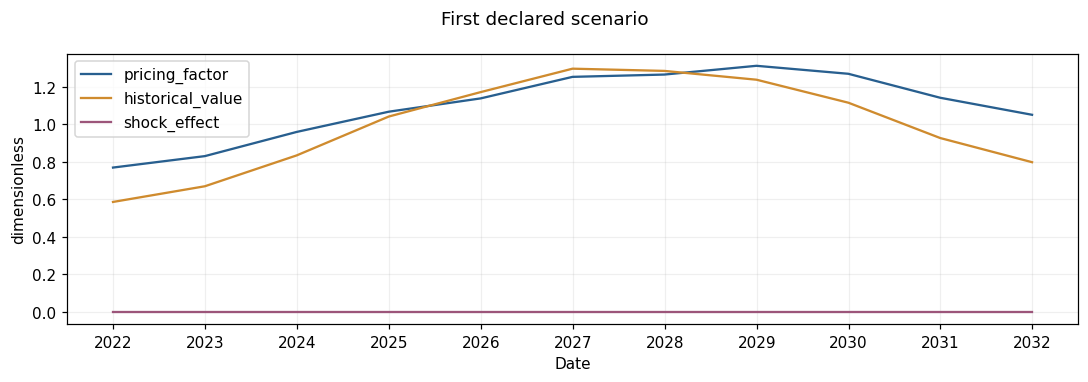

In [5]:
plot_flows({name: scenarios[0].value(name).flow for name in ('pricing_factor','historical_value','shock_effect')}, title='First declared scenario');

### 4. Author and formulate each investment

In [6]:
models = [investment.formulate(investment.author({'growth_rate': 0.}, scenario=scenario)) for scenario in scenarios]

### 5. Execute fixed-horizon investigations

In [7]:
fixed_results = [execute(model, investment.specify(model))[0] for model in models]

### 6. Execute policy investigations on those same Models

In [8]:
policies = [investment.build_policy(model, threshold=1.2, minimum_holding_periods=3) for model in models]
policy_results = [execute(model, investment.specify(model, policy=policy))[0] for model, policy in zip(models, policies)]

### 7. Inspect paired results

In [9]:
rows = [{'Scenario': scenario.realization.key, 'Fixed PV (AUD)': fixed.pv.magnitude, 'Policy PV (AUD)': chosen.pv.magnitude, 'PV difference (AUD)': chosen.pv.magnitude-fixed.pv.magnitude, 'Fixed IRR (%)': 100*fixed.irr.rate, 'Policy IRR (%)': 100*chosen.irr.rate, 'IRR difference (percentage points)': 100*(chosen.irr.rate-fixed.irr.rate), 'Policy sale': chosen.sale_date} for scenario, fixed, chosen in zip(scenarios, fixed_results, policy_results)]
results = pd.DataFrame(rows)
display(results.head(10))
results.select_dtypes('number').describe().round(3)

,Scenario,Fixed PV (AUD),Policy PV (AUD),PV difference (AUD),Fixed IRR (%),Policy IRR (%),IRR difference (percentage points),Policy sale
0,scenario-0000,816.980182,1113.287737,296.307555,4.323860,9.112985,4.789125,2026-12-31
1,scenario-0001,951.141353,951.141353,0.000000,6.355849,6.355849,0.000000,2030-12-31
2,scenario-0002,997.424545,997.424545,0.000000,6.963340,6.963340,0.000000,2030-12-31
3,scenario-0003,774.128403,1677.898207,903.769804,3.360857,27.945041,24.584184,2023-12-31


,Fixed PV (AUD),Policy PV (AUD),PV difference (AUD),Fixed IRR (%),Policy IRR (%),IRR difference (percentage points)
count,4.000,4.000,4.000,4.000,4.000,4.000
mean,884.919,1184.938,300.019,5.251,12.594,7.343
std,106.353,335.642,426.048,1.692,10.302,11.714
min,774.128,951.141,0.000,3.361,6.356,0.000
25%,806.267,985.854,0.000,4.083,6.811,0.000
50%,884.061,1055.356,148.154,5.340,8.038,2.395
75%,962.712,1254.440,448.173,6.508,13.821,9.738
max,997.425,1677.898,903.770,6.963,27.945,24.584


### 8. Compare PV distributions

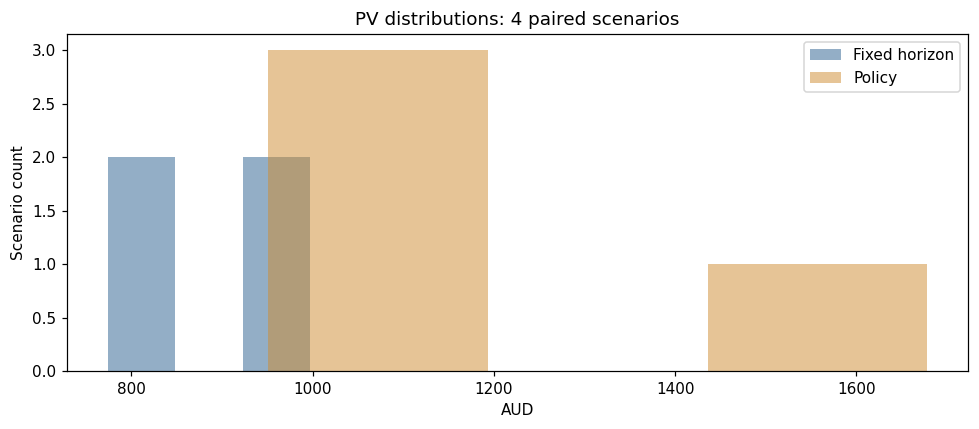

In [10]:
pv_samples = {'Fixed horizon': results['Fixed PV (AUD)'].tolist(), 'Policy': results['Policy PV (AUD)'].tolist()}
plot_distribution(pv_samples, units='AUD', title=f'PV distributions: {SCENARIO_COUNT} paired scenarios');

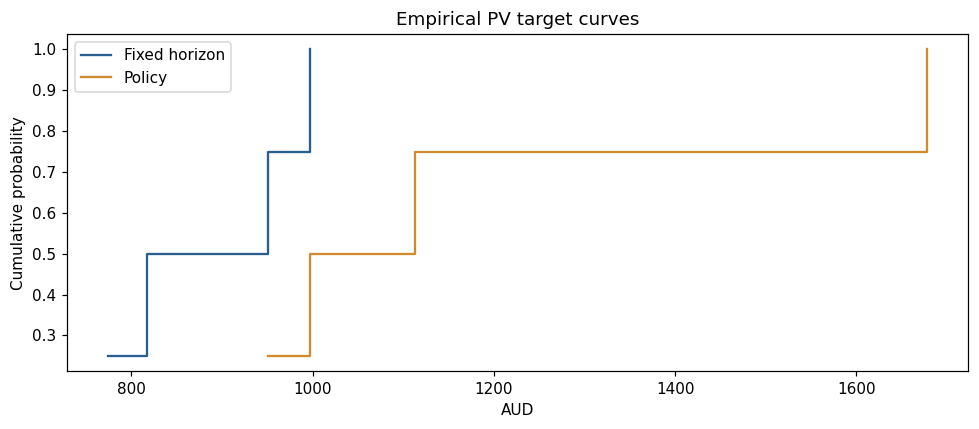

In [11]:
plot_distribution(pv_samples, units='AUD', cumulative=True, title='Empirical PV target curves');

### 9. Compare realized IRR distributions

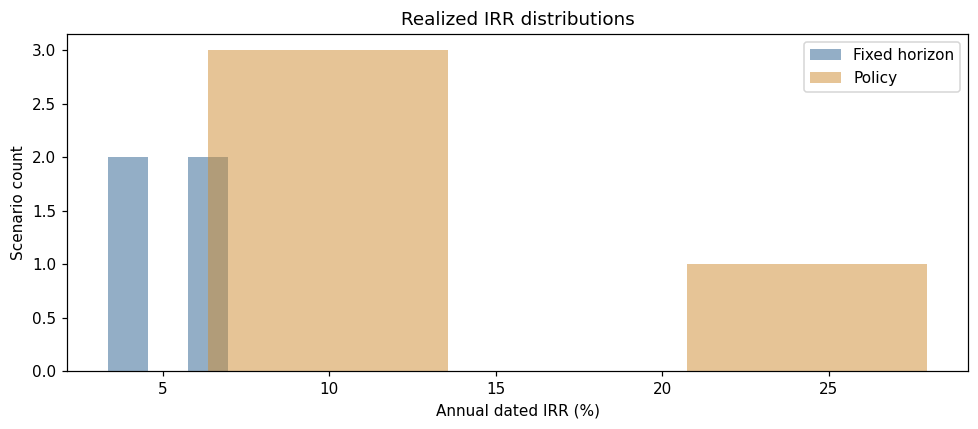

In [12]:
irr_samples = {'Fixed horizon': results['Fixed IRR (%)'].tolist(), 'Policy': results['Policy IRR (%)'].tolist()}
plot_distribution(irr_samples, units='Annual dated IRR (%)', title='Realized IRR distributions');

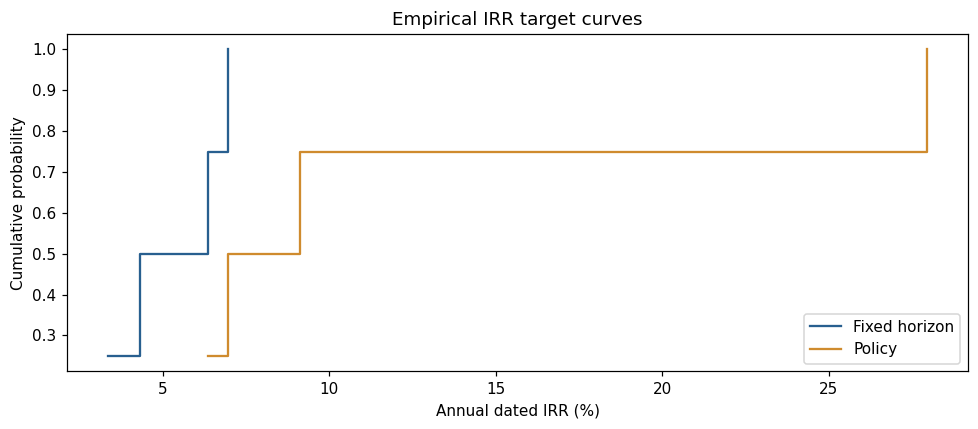

In [13]:
plot_distribution(irr_samples, units='Annual dated IRR (%)', cumulative=True, title='Empirical IRR target curves');

### 10. Inspect paired outcome relationships

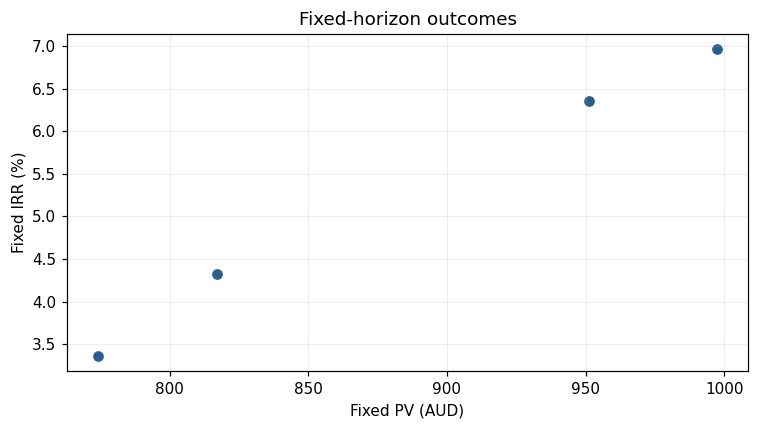

In [14]:
plot_pairs(results['Fixed PV (AUD)'].tolist(), results['Fixed IRR (%)'].tolist(), x_label='Fixed PV (AUD)', y_label='Fixed IRR (%)', title='Fixed-horizon outcomes');

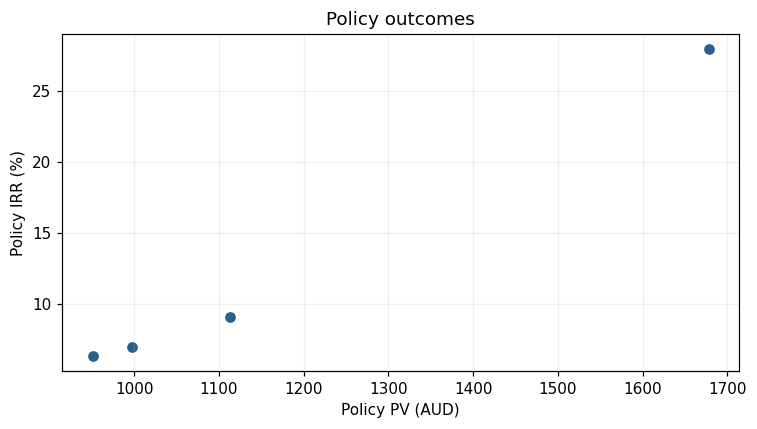

In [15]:
plot_pairs(results['Policy PV (AUD)'].tolist(), results['Policy IRR (%)'].tolist(), x_label='Policy PV (AUD)', y_label='Policy IRR (%)', title='Policy outcomes');

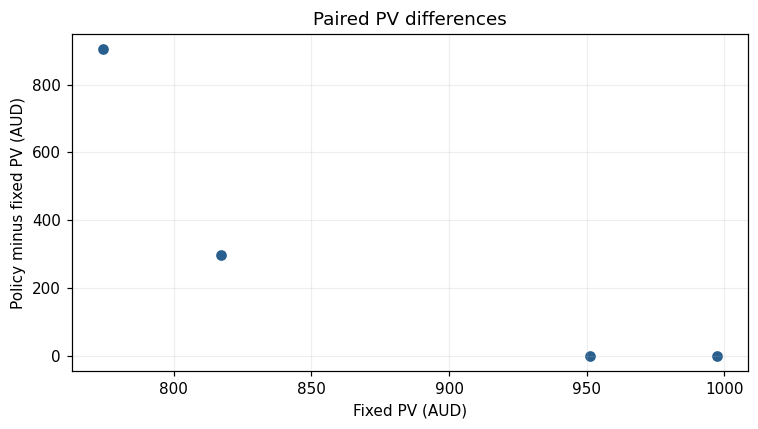

In [16]:
plot_pairs(results['Fixed PV (AUD)'].tolist(), results['PV difference (AUD)'].tolist(), x_label='Fixed PV (AUD)', y_label='Policy minus fixed PV (AUD)', title='Paired PV differences');

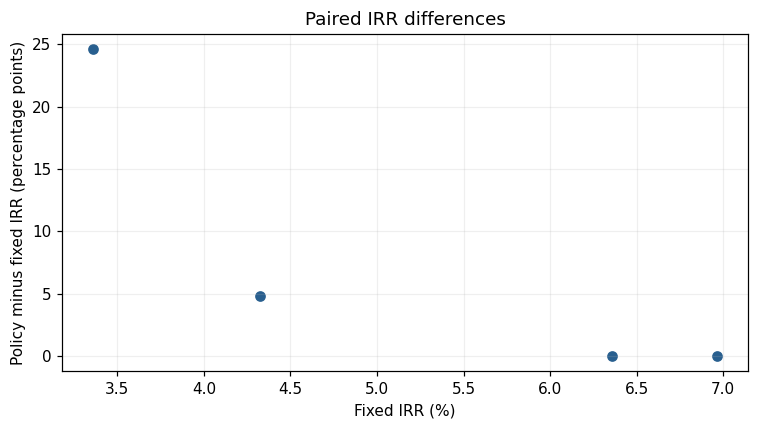

In [17]:
plot_pairs(results['Fixed IRR (%)'].tolist(), results['IRR difference (percentage points)'].tolist(), x_label='Fixed IRR (%)', y_label='Policy minus fixed IRR (percentage points)', title='Paired IRR differences');

## Checks

In [18]:
assert len(results) == SCENARIO_COUNT
assert all(replay(scenario.model).model.id == scenario.model.id for scenario in scenarios)
assert all(len(scenario.value('historical_value').flow.movements) == 11 for scenario in scenarios)
print('Paired realized inputs and captured-path replay verified.')

Paired realized inputs and captured-path replay verified.


In [19]:
assert not {'rangekeeper.flux','rangekeeper.dynamics','rangekeeper.policy','rangekeeper._legacy_duration'} & set(sys.modules)
print('Canonical records, explicit roles and installed consumer checks passed.')

Canonical records, explicit roles and installed consumer checks passed.


## Next Steps
Use the full 2,000-scenario setting for a larger study, then test sensitivity to parameters, seeds and thresholds. Keep paired realizations. Threshold rules do not guarantee market-peak sales, positive value differences or numerical feasibility for other formulations.